In [1]:
"""01 - Data Exploration

Goal: inspect actual values, dtypes, ranges, and class distributions for
the DFC2020 validation set. Decisions made here drive normalization,
class weighting, and visualization choices throughout the project.
"""

import os
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

%matplotlib inline
np.set_printoptions(suppress=True, precision=3)

In [2]:
# Project paths, anchored on the data root so this notebook is location-independent
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw"

VAL_DIR = DATA_ROOT / "ROIs0000_validation"
S1_DIR = VAL_DIR / "s1_validation"
S2_DIR = VAL_DIR / "s2_validation"
DFC_DIR = VAL_DIR / "dfc_validation"

# Sanity check, fail loudly if anything is missing
for d in (S1_DIR, S2_DIR, DFC_DIR):
    assert d.exists(), f"Missing directory: {d}"
    n = len(list(d.glob("*.tif")))
    print(f"{d.name:<20s}  {n:>5d} patches")

s1_validation           986 patches
s2_validation           986 patches
dfc_validation          986 patches


In [3]:
# Pick a sample patch ID - p0 is as good as any
PATCH_ID = "p0"
SCENE_ID = "0"  # only one scene in validation ("0")

s1_path = S1_DIR / f"ROIs0000_validation_s1_{SCENE_ID}_{PATCH_ID}.tif"
print(f"Opening: {s1_path.name}")

with rasterio.open(s1_path) as src:
    print(f"  shape:      {src.count} bands x {src.height} x {src.width}")
    print(f"  dtype:      {src.dtypes[0]}")
    print(f"  CRS:        {src.crs}")
    print(f"  transform:  {src.transform}")
    print(f"  nodata:     {src.nodata}")
    
    s1 = src.read()  # shape: (bands, H, W)

print(f"\nArray shape: {s1.shape}")
print(f"Array dtype: {s1.dtype}")

Opening: ROIs0000_validation_s1_0_p0.tif
  shape:      2 bands x 256 x 256
  dtype:      float64
  CRS:        GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  transform:  | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
  nodata:     None

Array shape: (2, 256, 256)
Array dtype: float64


In [4]:
# Sentinel-1 GRD in DFC2020 is distributed as dB-scaled backscatter
# Channels: 0 = VV, 1 = VH
# Expected range: roughly [-30, 0] dB for typical Earth surfaces

vv = s1[0]
vh = s1[1]

print("VV channel:")
print(f"  min:    {vv.min():.3f}")
print(f"  max:    {vv.max():.3f}")
print(f"  mean:   {vv.mean():.3f}")
print(f"  std:    {vv.std():.3f}")
print(f"  median: {np.median(vv):.3f}")
print(f"  p1, p99: {np.percentile(vv, [1, 99])}")

print("\nVH channel:")
print(f"  min:    {vh.min():.3f}")
print(f"  max:    {vh.max():.3f}")
print(f"  mean:   {vh.mean():.3f}")
print(f"  std:    {vh.std():.3f}")
print(f"  median: {np.median(vh):.3f}")
print(f"  p1, p99: {np.percentile(vh, [1, 99])}")

# NaN / infinity check, common in SAR data due to processing artifacts
print(f"\nNaN count: VV={np.isnan(vv).sum()}, VH={np.isnan(vh).sum()}")
print(f"Inf count: VV={np.isinf(vv).sum()}, VH={np.isinf(vh).sum()}")

VV channel:
  min:    -24.257
  max:    3.847
  mean:   -12.267
  std:    6.028
  median: -14.554
  p1, p99: [-20.846   1.291]

VH channel:
  min:    -30.976
  max:    -3.974
  mean:   -17.997
  std:    4.988
  median: -19.434
  p1, p99: [-25.915  -6.98 ]

NaN count: VV=0, VH=0
Inf count: VV=0, VH=0


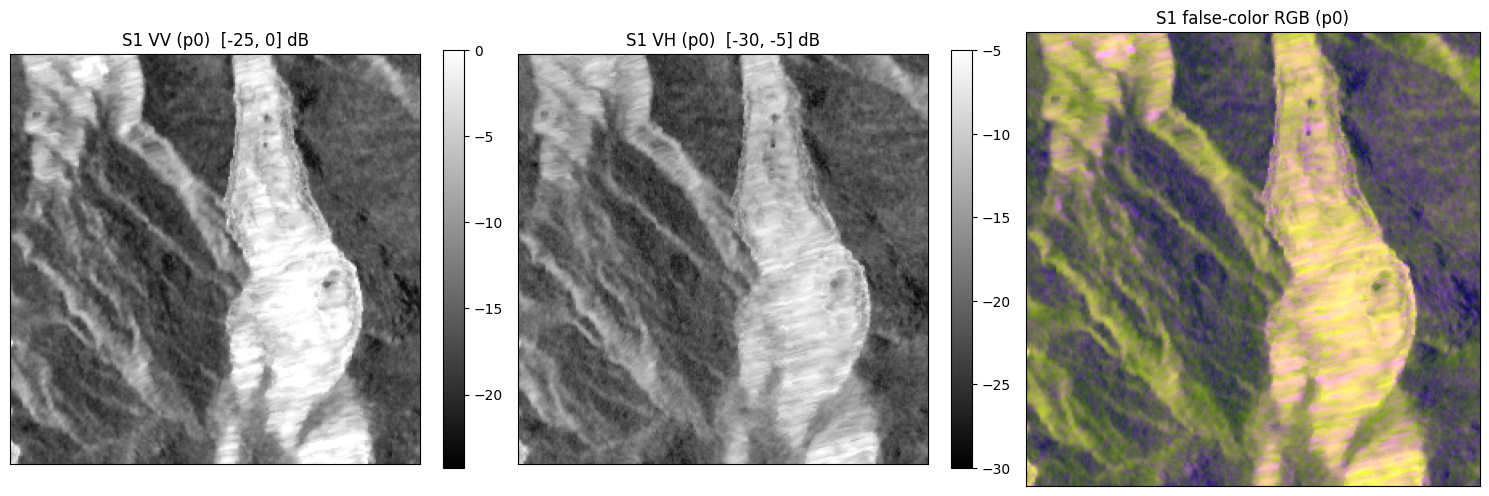

In [7]:
# Display VV, VH, and a false-color composite
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Clip to typical SAR display range for visualization (not for stats above!)
vv_disp = np.clip(vv, -25, 0)
vh_disp = np.clip(vh, -30, -5)

im0 = axes[0].imshow(vv_disp, cmap="gray")
axes[0].set_title(f"S1 VV ({PATCH_ID})  [-25, 0] dB")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(vh_disp, cmap="gray")
axes[1].set_title(f"S1 VH ({PATCH_ID})  [-30, -5] dB")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# False-color RGB: R=VV, G=VH, B=VV-VH (common SAR colorization)
def norm01(x, lo, hi):
    return np.clip((x - lo) / (hi - lo), 0, 1)

rgb = np.dstack([
    norm01(vv, -25, 0),
    norm01(vh, -30, -5),
    norm01(vv - vh, 0, 15),
])
axes[2].imshow(rgb)
axes[2].set_title(f"S1 false-color RGB ({PATCH_ID})")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## VV (grayscale) | VH (Grayscale) | RGB Composite

In [ ]:
# Open the S2 patch with the same patch ID
s2_path = S2_DIR / f"ROIs0000_validation_s2_{SCENE_ID}_{PATCH_ID}.tif"
print(f"Opening: {s2_path.name}")

with rasterio.open(s2_path) as src:
    print(f"  shape:      {src.count} bands x {src.height} x {src.width}")
    print(f"  dtype:      {src.dtypes[0]}")
    print(f"  CRS:        {src.crs}")
    print(f"  nodata:     {src.nodata}")
    s2 = src.read()  # shape: (bands, H, W)

print(f"\nArray shape: {s2.shape}")
print(f"Array dtype: {s2.dtype}")

Opening: ROIs0000_validation_s2_0_p0.tif
  shape:      13 bands x 256 x 256
  dtype:      uint16
  CRS:        GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  nodata:     None

Array shape: (13, 256, 256)
Array dtype: uint16


In [9]:
# Per-band statistics, S2 reflectance is stored as uint16 (reflectance * 10000)
# So a value of 1500 means reflectance of 0.15

S2_BAND_NAMES = [
    "B1 (coastal)", "B2 (blue)", "B3 (green)", "B4 (red)",
    "B5 (RE1)", "B6 (RE2)", "B7 (RE3)", "B8 (NIR)",
    "B8A (nNIR)", "B9 (water vapor)", "B10 (cirrus)", "B11 (SWIR1)", "B12 (SWIR2)",
]

print(f"{'Band':<20s} {'min':>8s} {'p1':>8s} {'mean':>8s} {'median':>8s} {'p99':>8s} {'max':>8s}")
print("-" * 70)
for i, name in enumerate(S2_BAND_NAMES):
    band = s2[i]
    p1, p99 = np.percentile(band, [1, 99])
    print(f"{name:<20s} {band.min():>8.0f} {p1:>8.0f} {band.mean():>8.0f} "
          f"{np.median(band):>8.0f} {p99:>8.0f} {band.max():>8.0f}")

Band                      min       p1     mean   median      p99      max
----------------------------------------------------------------------
B1 (coastal)              947      967     1071     1059     1251     1304
B2 (blue)                 612      674      824      802     1119     1456
B3 (green)                385      496      711      695     1006     1388
B4 (red)                  219      331      599      583      962     1373
B5 (RE1)                  249      496      896      899     1202     1384
B6 (RE2)                  397      828     1449     1448     2113     2754
B7 (RE3)                  435      908     1650     1643     2477     3416
B8 (NIR)                  359      892     1723     1715     2645     3736
B8A (nNIR)                446     1022     1890     1886     2849     3851
B9 (water vapor)          487      612     1010     1007     1405     1556
B10 (cirrus)                8        9       16       15       30       41
B11 (SWIR1)               335

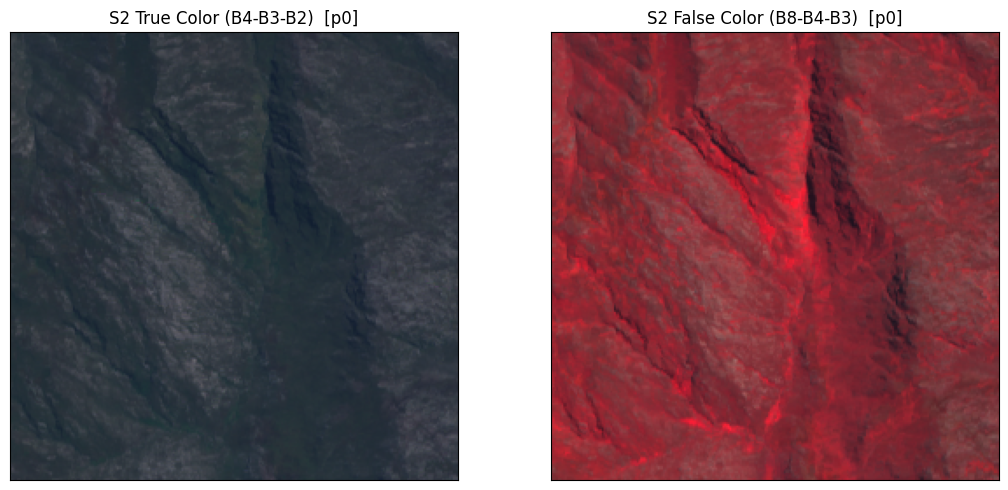

In [10]:
# RGB true-color: bands 4, 3, 2 (red, green, blue in S2 numbering = indices 3, 2, 1)
# Reflectance values stored as *10000, so divide
rgb_true = np.dstack([s2[3], s2[2], s2[1]]).astype(np.float32) / 10000.0
rgb_true = np.clip(rgb_true * 3.0, 0, 1)  # ×3 stretch for visibility (most reflectances are low)

# False-color: NIR, Red, Green (highlights vegetation in red)
rgb_false = np.dstack([s2[7], s2[3], s2[2]]).astype(np.float32) / 10000.0
rgb_false = np.clip(rgb_false * 3.0, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(rgb_true)
axes[0].set_title(f"S2 True Color (B4-B3-B2)  [{PATCH_ID}]")
axes[1].imshow(rgb_false)
axes[1].set_title(f"S2 False Color (B8-B4-B3)  [{PATCH_ID}]")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [11]:
# Open the DFC label patch
dfc_path = DFC_DIR / f"ROIs0000_validation_dfc_{SCENE_ID}_{PATCH_ID}.tif"
print(f"Opening: {dfc_path.name}")

with rasterio.open(dfc_path) as src:
    print(f"  shape:      {src.count} bands x {src.height} x {src.width}")
    print(f"  dtype:      {src.dtypes[0]}")
    print(f"  CRS:        {src.crs}")
    print(f"  nodata:     {src.nodata}")
    label = src.read(1)  # single band, shape: (H, W)

print(f"\nArray shape: {label.shape}")
print(f"Array dtype: {label.dtype}")
print(f"Unique values in this patch: {np.unique(label)}")
print(f"Value range: [{label.min()}, {label.max()}]")

Opening: ROIs0000_validation_dfc_0_p0.tif
  shape:      1 bands x 256 x 256
  dtype:      int32
  CRS:        GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  nodata:     None

Array shape: (256, 256)
Array dtype: int32
Unique values in this patch: [1 2 5 6 7 9]
Value range: [1, 9]


Classes in this patch: 1=Forest, 2=Shrubland, 5=Wetlands, 6=Croplands, 7=Urban, 9=Barren

Pixel breakdown:
   1 Forest        12781 pixels  (19.50 %)
   2 Shrubland       955 pixels  ( 1.46 %)
   5 Wetlands         25 pixels  ( 0.04 %)
   6 Croplands       399 pixels  ( 0.61 %)
   7 Urban            27 pixels  ( 0.04 %)
   9 Barren        51349 pixels  (78.35 %)


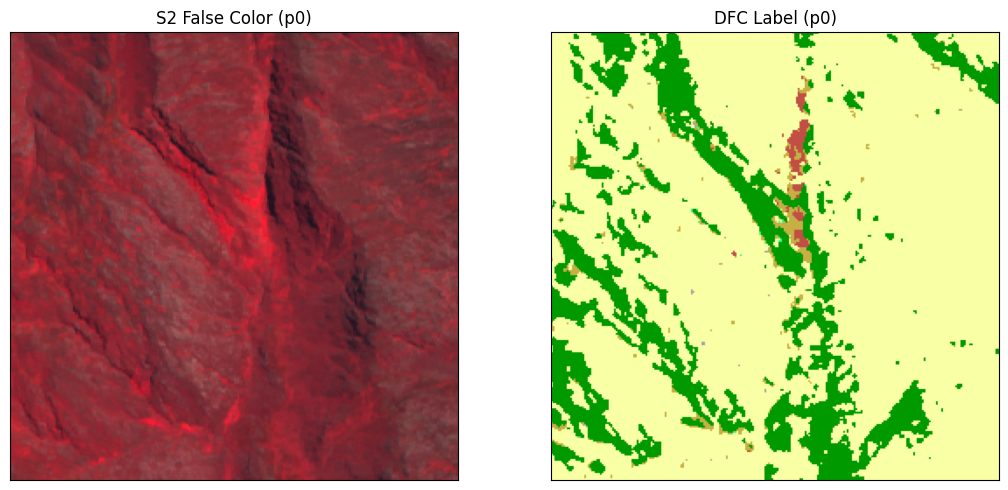

In [12]:
# Define the DFC color scheme — standard from the contest
DFC_CLASS_NAMES = {
    0: "No data",
    1: "Forest",
    2: "Shrubland",
    3: "Savanna",
    4: "Grassland",
    5: "Wetlands",
    6: "Croplands",
    7: "Urban",
    8: "Snow/Ice",
    9: "Barren",
    10: "Water",
}

# Color scheme roughly matching DFC2020 convention
DFC_COLORS = {
    0: "#000000",  # black: no data
    1: "#009900",  # dark green: forest
    2: "#c6b044",  # olive: shrubland
    3: "#fbff13",  # yellow: savanna
    4: "#b6ff05",  # light green: grassland
    5: "#27ff87",  # cyan-green: wetlands
    6: "#c24f44",  # red-brown: croplands
    7: "#a5a5a5",  # gray: urban
    8: "#ffffff",  # white: snow/ice
    9: "#f9ffa4",  # pale: barren
    10: "#1c0dff", # blue: water
}

# Build the discrete colormap
max_class = 10
color_list = [DFC_COLORS[i] for i in range(max_class + 1)]
cmap = ListedColormap(color_list)
norm = BoundaryNorm(np.arange(-0.5, max_class + 1.5, 1), cmap.N)

# Plot label alongside the S2 false-color for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# S2 false color (reusing from above logic)
rgb_false = np.dstack([s2[7], s2[3], s2[2]]).astype(np.float32) / 10000.0
rgb_false = np.clip(rgb_false * 3.0, 0, 1)
axes[0].imshow(rgb_false)
axes[0].set_title(f"S2 False Color ({PATCH_ID})")
axes[0].set_xticks([]); axes[0].set_yticks([])

im = axes[1].imshow(label, cmap=cmap, norm=norm)
axes[1].set_title(f"DFC Label ({PATCH_ID})")
axes[1].set_xticks([]); axes[1].set_yticks([])

# Show which classes are present in this patch
present = np.unique(label)
present_str = ", ".join([f"{c}={DFC_CLASS_NAMES[c]}" for c in present])
print(f"Classes in this patch: {present_str}")

# Pixel counts for each class
print("\nPixel breakdown:")
for c in present:
    count = int((label == c).sum())
    pct = 100 * count / label.size
    print(f"  {c:>2d} {DFC_CLASS_NAMES[c]:<12s} {count:>6d} pixels  ({pct:5.2f} %)")

plt.tight_layout()
plt.show()

In [13]:
from tqdm import tqdm
from collections import Counter

# Get sorted patch ID list
patch_files_s1 = sorted(S1_DIR.glob("*.tif"))
N = len(patch_files_s1)
print(f"Processing {N} validation patches...")

# Extract patch IDs (e.g., "p0", "p1", ...) for cross-modal pairing
def patch_id_from_path(p):
    # Filename: ROIs0000_validation_s1_0_p0.tif → "p0"
    return p.stem.split("_")[-1]

# Storage for statistics
s1_channel_stats = {0: [], 1: []}  # per-channel pixel values (sampled)
s2_channel_stats = {i: [] for i in range(13)}
class_pixel_counts = Counter()
patches_with_class_zero = []
shape_mismatches = []

# We don't need every pixel. Sample ~5000 per patch per channel for global stats
N_SAMPLES_PER_PATCH = 5000
rng = np.random.default_rng(seed=42)

for s1_path in tqdm(patch_files_s1):
    pid = patch_id_from_path(s1_path)
    s2_path = S2_DIR / f"ROIs0000_validation_s2_{SCENE_ID}_{pid}.tif"
    dfc_path = DFC_DIR / f"ROIs0000_validation_dfc_{SCENE_ID}_{pid}.tif"

    # Existence check
    if not s2_path.exists() or not dfc_path.exists():
        shape_mismatches.append(pid + " (missing pair)")
        continue

    # Read all three
    with rasterio.open(s1_path) as src:
        s1_arr = src.read()
    with rasterio.open(s2_path) as src:
        s2_arr = src.read()
    with rasterio.open(dfc_path) as src:
        lbl = src.read(1)

    # Shape sanity check
    if s1_arr.shape != (2, 256, 256) or s2_arr.shape != (13, 256, 256) or lbl.shape != (256, 256):
        shape_mismatches.append(f"{pid} (shapes {s1_arr.shape}/{s2_arr.shape}/{lbl.shape})")
        continue

    # Sample S1 pixels per channel
    flat_idx = rng.choice(256 * 256, size=N_SAMPLES_PER_PATCH, replace=False)
    for c in range(2):
        s1_channel_stats[c].append(s1_arr[c].ravel()[flat_idx])
    # Same for S2
    for c in range(13):
        s2_channel_stats[c].append(s2_arr[c].ravel()[flat_idx])

    # Class counts — full patch (cheap)
    vals, counts = np.unique(lbl, return_counts=True)
    for v, cnt in zip(vals, counts):
        class_pixel_counts[int(v)] += int(cnt)

    if 0 in vals:
        patches_with_class_zero.append(pid)

print(f"\nDone. Shape issues: {len(shape_mismatches)}")
if shape_mismatches:
    print("First few:", shape_mismatches[:5])
print(f"Patches containing class 0 (no-data): {len(patches_with_class_zero)}")

Processing 986 validation patches...


100%|██████████| 986/986 [01:59<00:00,  8.25it/s]


Done. Shape issues: 0
Patches containing class 0 (no-data): 0


In [14]:
# Compute per-channel stats from sampled values
print("=" * 76)
print("S1 channel statistics (over 986 patches × 5000 samples each)")
print("=" * 76)
print(f"{'Channel':<8s} {'mean':>10s} {'std':>10s} {'p1':>10s} {'p99':>10s} {'min':>10s} {'max':>10s}")
for c, name in enumerate(["VV", "VH"]):
    vals = np.concatenate(s1_channel_stats[c])
    print(f"{name:<8s} {vals.mean():>10.3f} {vals.std():>10.3f} "
          f"{np.percentile(vals, 1):>10.3f} {np.percentile(vals, 99):>10.3f} "
          f"{vals.min():>10.3f} {vals.max():>10.3f}")

print()
print("=" * 76)
print("S2 channel statistics (over 986 patches × 5000 samples each)")
print("=" * 76)
print(f"{'Band':<20s} {'mean':>10s} {'std':>10s} {'p1':>10s} {'p99':>10s} {'min':>10s} {'max':>10s}")
for c, name in enumerate(S2_BAND_NAMES):
    vals = np.concatenate(s2_channel_stats[c])
    print(f"{name:<20s} {vals.mean():>10.0f} {vals.std():>10.0f} "
          f"{np.percentile(vals, 1):>10.0f} {np.percentile(vals, 99):>10.0f} "
          f"{vals.min():>10.0f} {vals.max():>10.0f}")

S1 channel statistics (over 986 patches × 5000 samples each)
Channel        mean        std         p1        p99        min        max
VV          -13.946      4.329    -23.178     -4.164    -48.507     25.524
VH          -21.538      6.001    -34.390    -11.792    -48.988     20.834

S2 channel statistics (over 986 patches × 5000 samples each)
Band                       mean        std         p1        p99        min        max
B1 (coastal)               1354        170       1062       1895        930       5389
B2 (blue)                  1094        246        740       1885        616      13899
B3 (green)                 1000        299        466       1957        364      15503
B4 (red)                    811        477        249       2465        202      15167
B5 (RE1)                   1072        499        211       2678        101      15333
B6 (RE2)                   1894       1057        178       3651         80      19633
B7 (RE3)                   2212       1336 

In [15]:
total_pixels = sum(class_pixel_counts.values())
print(f"\nTotal labeled pixels: {total_pixels:,}")
print(f"\n{'ID':>3s}  {'Class':<14s} {'Pixels':>12s} {'% of total':>11s}")
print("-" * 46)
for cls_id in sorted(class_pixel_counts.keys()):
    count = class_pixel_counts[cls_id]
    pct = 100.0 * count / total_pixels
    name = DFC_CLASS_NAMES.get(cls_id, f"Unknown {cls_id}")
    print(f"{cls_id:>3d}  {name:<14s} {count:>12,d} {pct:>10.3f} %")

# Class imbalance ratio: most common to least common
counts_sorted = sorted([c for c in class_pixel_counts.values() if c > 0], reverse=True)
if len(counts_sorted) > 1:
    imbalance = counts_sorted[0] / counts_sorted[-1]
    print(f"\nMax/min imbalance ratio: {imbalance:.1f}x")


Total labeled pixels: 64,618,496

 ID  Class                Pixels  % of total
----------------------------------------------
  1  Forest            5,904,112      9.137 %
  2  Shrubland         3,353,501      5.190 %
  4  Grassland         7,655,859     11.848 %
  5  Wetlands         11,272,496     17.445 %
  6  Croplands         8,405,224     13.007 %
  7  Urban             3,517,590      5.444 %
  9  Barren            1,887,823      2.921 %
 10  Water            22,621,891     35.008 %

Max/min imbalance ratio: 12.0x


In [16]:
import json

# Per-channel S1 stats (in dB)
s1_stats = {}
for c, name in enumerate(["vv", "vh"]):
    vals = np.concatenate(s1_channel_stats[c])
    s1_stats[name] = {
        "mean": float(vals.mean()),
        "std": float(vals.std()),
        "p1": float(np.percentile(vals, 1)),
        "p99": float(np.percentile(vals, 99)),
    }

# Per-band S2 stats (raw uint16)
s2_band_keys = ["b1", "b2", "b3", "b4", "b5", "b6", "b7", "b8", "b8a", "b9", "b10", "b11", "b12"]
s2_stats = {}
for c, key in enumerate(s2_band_keys):
    vals = np.concatenate(s2_channel_stats[c])
    s2_stats[key] = {
        "mean": float(vals.mean()),
        "std": float(vals.std()),
        "p1": float(np.percentile(vals, 1)),
        "p99": float(np.percentile(vals, 99)),
    }

# Class statistics
class_stats = {
    "total_labeled_pixels": int(total_pixels),
    "per_class_count": {int(k): int(v) for k, v in class_pixel_counts.items()},
    "present_classes": sorted([int(k) for k in class_pixel_counts.keys() if class_pixel_counts[k] > 0]),
    "missing_classes": sorted([int(k) for k in range(11) if class_pixel_counts.get(k, 0) == 0]),
    "class_names": DFC_CLASS_NAMES,
}

dataset_stats = {
    "source": "DFC2020 validation set (986 patches)",
    "computed_at": str(np.datetime64("now")),
    "sample_pixels_per_patch": N_SAMPLES_PER_PATCH,
    "s1": s1_stats,
    "s2": s2_stats,
    "classes": class_stats,
    "notes": [
        "S1 values are dB-scaled backscatter (float64 in source, cast to float32 in pipeline).",
        "S2 values are uint16 reflectance * 10000.",
        "B10 has near-zero dynamic range (mean ~11, std ~5) — recommended to drop in dataset class.",
        "Class 3 (Savanna) and class 8 (Snow/Ice) are absent — treat as 8-class problem.",
        "Class 0 (No data) does not appear in any patch — no ignore_index needed.",
        "Recommend per-channel clip to [p1, p99] then z-score normalize.",
        "Recommend class-weighted loss due to 12x imbalance ratio (Water dominant)."
    ],
}

# Write to file inside src/ so it ships with the package
stats_path = PROJECT_ROOT / "src" / "sar_optical_fusion" / "data" / "dataset_stats.json"
stats_path.parent.mkdir(parents=True, exist_ok=True)
with open(stats_path, "w") as f:
    json.dump(dataset_stats, f, indent=2)

print(f"Saved dataset statistics to: {stats_path}")
print(f"File size: {stats_path.stat().st_size:,} bytes")

Saved dataset statistics to: d:\Projects\sar-optical-fusion-dfc2020\src\sar_optical_fusion\data\dataset_stats.json
File size: 3,493 bytes
